In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [4]:
df = pd.read_csv(r"C:\Users\Nishant Pandey\Downloads\reliance_digital_sales_trend_dataset.csv")

In [5]:
df['Month'] = pd.to_datetime(df['Month'])

print(df.head())

       Month         Category  Units_Sold  Revenue_INR
0 2023-01-01      Smartphones          52      1392324
1 2023-01-01          Laptops          30      1061002
2 2023-01-01      Televisions          16       707503
3 2023-01-01  Home Appliances          24       925960
4 2023-01-01      Accessories          11       305455


In [6]:
print("\nDataset Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())


Dataset Shape: (180, 4)

Columns:
Index(['Month', 'Category', 'Units_Sold', 'Revenue_INR'], dtype='object')

Missing Values:
Month          0
Category       0
Units_Sold     0
Revenue_INR    0
dtype: int64


In [7]:
total_revenue = df['Revenue_INR'].sum()
total_units = df['Units_Sold'].sum()

avg_revenue = df['Revenue_INR'].mean()

print("\n=========== KPI SUMMARY ===========")
print(f"Total Revenue : ₹{total_revenue:,.0f}")
print(f"Total Units Sold : {total_units:,}")
print(f"Average Revenue : ₹{avg_revenue:,.0f}")


=========== KPI SUMMARY ===========
Total Revenue : ₹162,114,508
Total Units Sold : 6,169
Average Revenue : ₹900,636


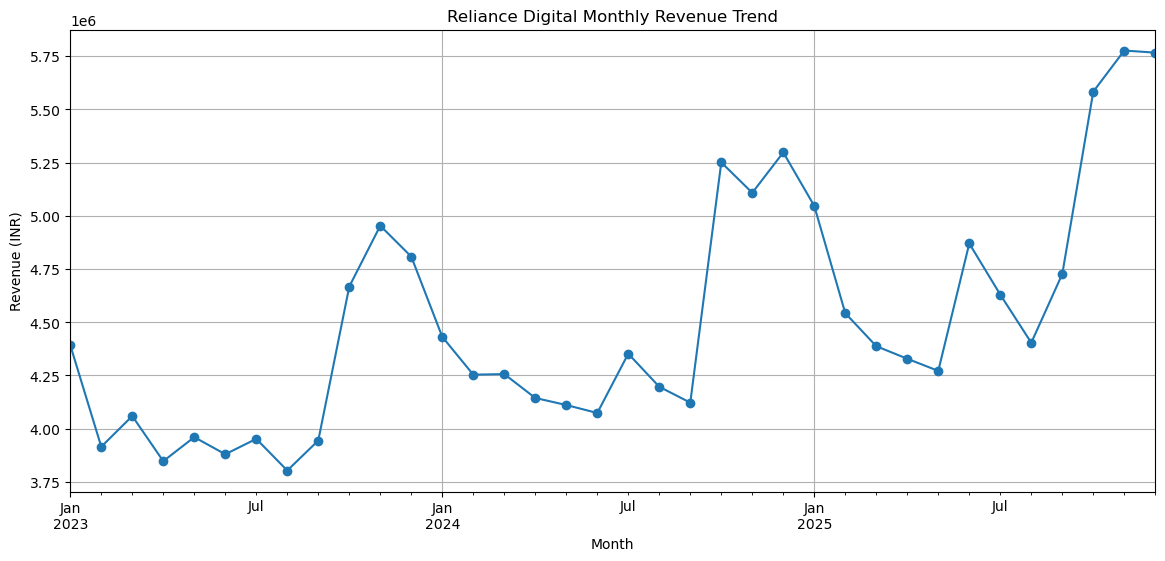

In [8]:
monthly_sales = df.groupby('Month')['Revenue_INR'].sum()

plt.figure(figsize=(14,6))
monthly_sales.plot(marker='o')

plt.title("Reliance Digital Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (INR)")
plt.grid(True)

plt.show()

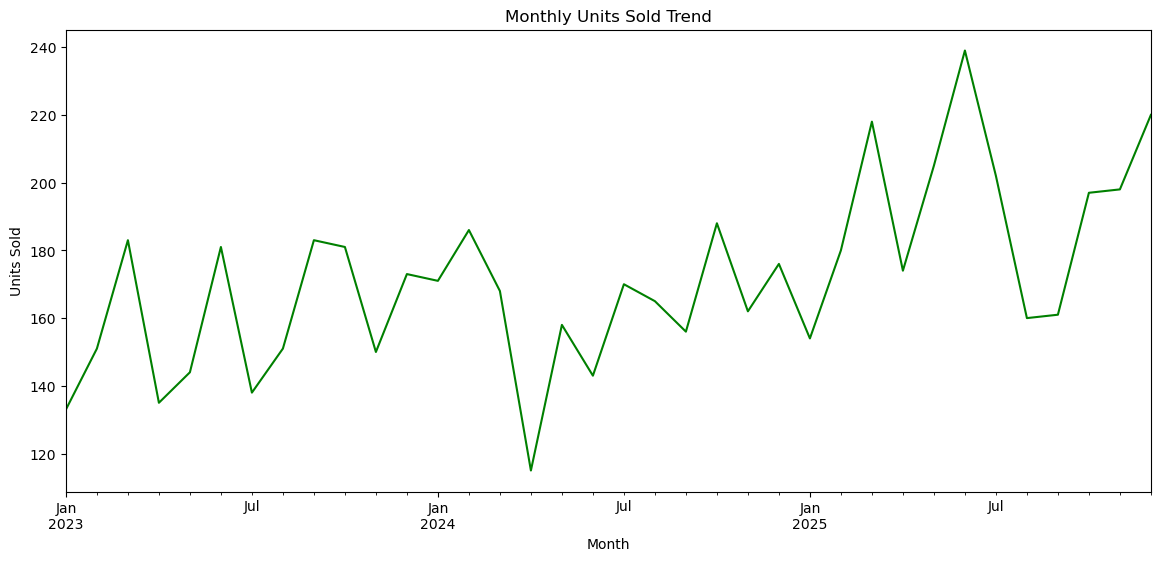

In [9]:
monthly_units = df.groupby('Month')['Units_Sold'].sum()

plt.figure(figsize=(14,6))
monthly_units.plot(color='green')

plt.title("Monthly Units Sold Trend")
plt.xlabel("Month")
plt.ylabel("Units Sold")

plt.show()

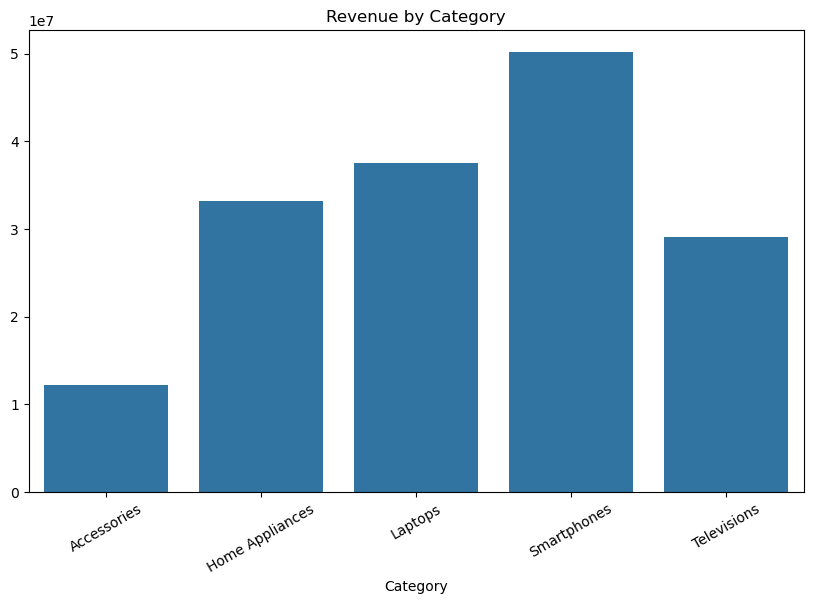

In [10]:
category_revenue = df.groupby('Category')['Revenue_INR'].sum()

plt.figure(figsize=(10,6))

sns.barplot(
    x=category_revenue.index,
    y=category_revenue.values
)

plt.title("Revenue by Category")

plt.xticks(rotation=30)

plt.show()


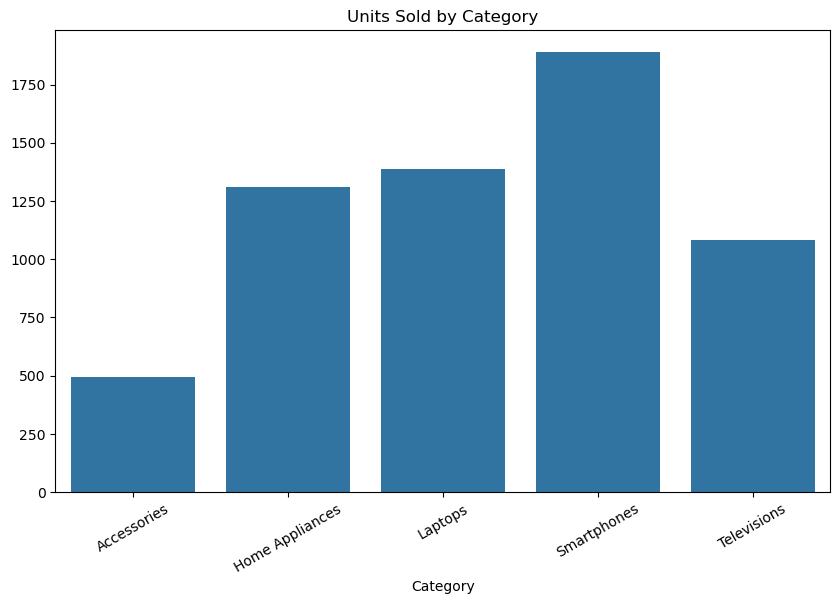

In [11]:
category_units = df.groupby('Category')['Units_Sold'].sum()

plt.figure(figsize=(10,6))

sns.barplot(
    x=category_units.index,
    y=category_units.values
)

plt.title("Units Sold by Category")

plt.xticks(rotation=30)

plt.show()

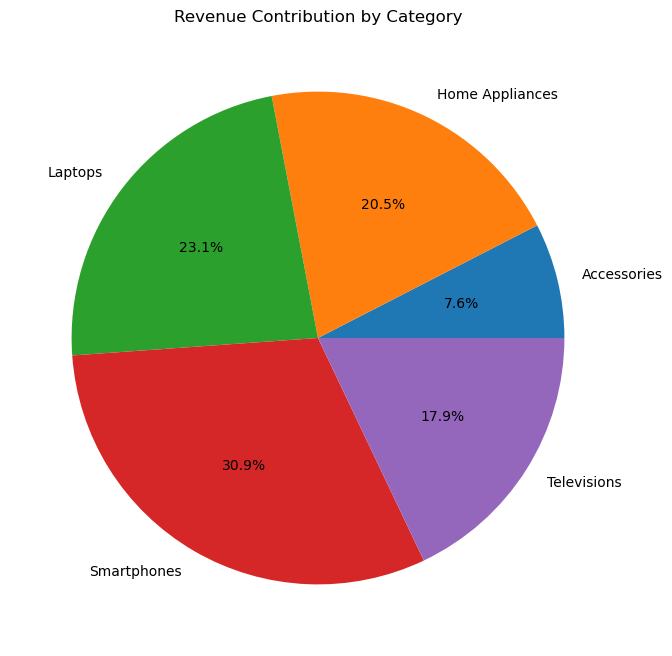

In [12]:
plt.figure(figsize=(8,8))

plt.pie(
    category_revenue,
    labels=category_revenue.index,
    autopct='%1.1f%%'
)

plt.title("Revenue Contribution by Category")

plt.show()


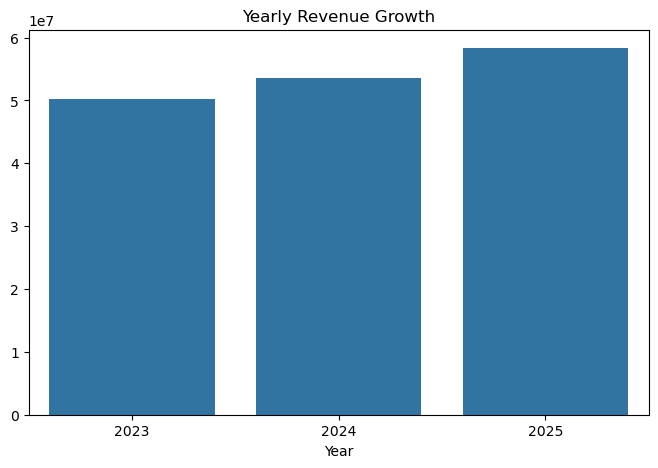

In [13]:
df['Year'] = df['Month'].dt.year

yearly_revenue = df.groupby('Year')['Revenue_INR'].sum()

plt.figure(figsize=(8,5))

sns.barplot(
    x=yearly_revenue.index,
    y=yearly_revenue.values
)

plt.title("Yearly Revenue Growth")

plt.show()


Yearly Growth %
Year
2023         NaN
2024    6.803484
2025    8.828585
Name: Revenue_INR, dtype: float64


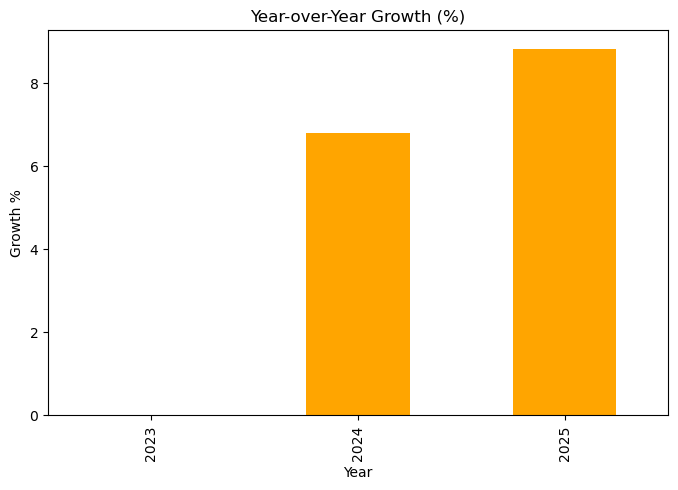

In [14]:
growth = yearly_revenue.pct_change()*100

print("\nYearly Growth %")
print(growth)

plt.figure(figsize=(8,5))

growth.plot(
    kind='bar',
    color='orange'
)

plt.title("Year-over-Year Growth (%)")
plt.ylabel("Growth %")

plt.show()

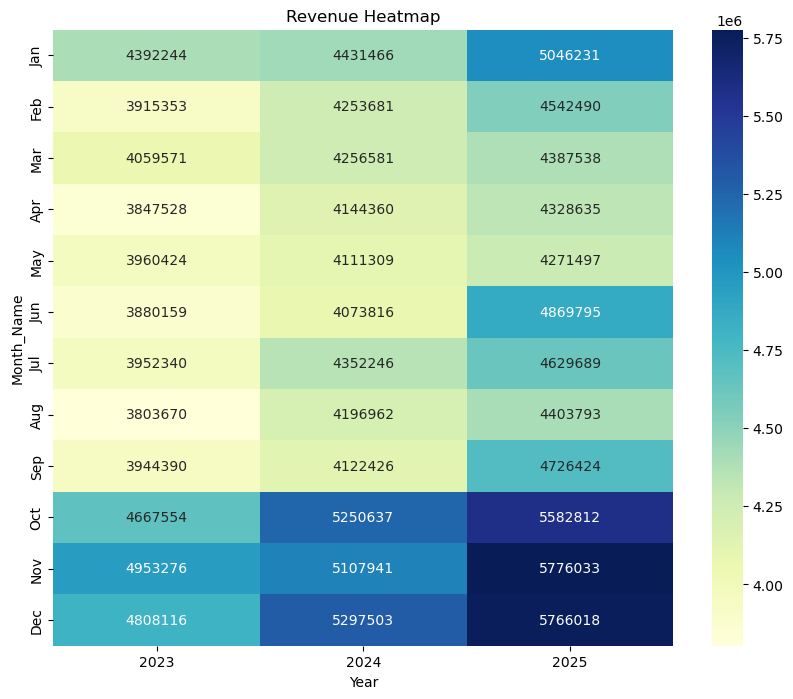

In [15]:
df['Year'] = df['Month'].dt.year
df['Month_Name'] = df['Month'].dt.strftime('%b')

heatmap_data = pd.pivot_table(
    df,
    values='Revenue_INR',
    index='Month_Name',
    columns='Year',
    aggfunc='sum'
)

month_order = [
    'Jan','Feb','Mar','Apr',
    'May','Jun','Jul','Aug',
    'Sep','Oct','Nov','Dec'
]

heatmap_data = heatmap_data.reindex(month_order)

plt.figure(figsize=(10,8))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.0f',
    cmap='YlGnBu'
)

plt.title("Revenue Heatmap")

plt.show()

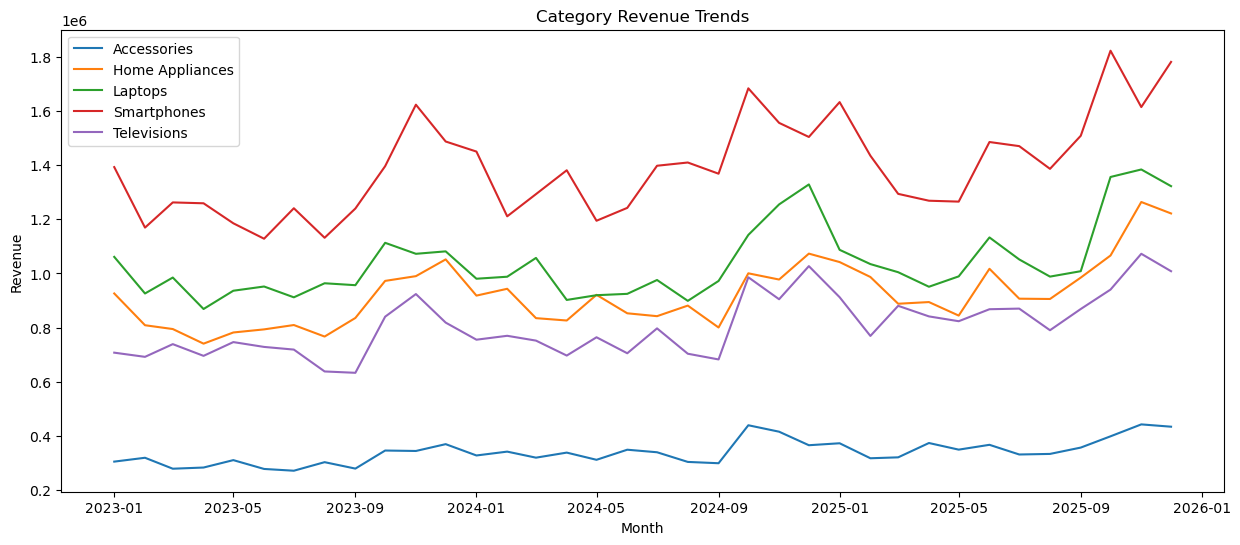

In [16]:
category_monthly = df.pivot_table(
    index='Month',
    columns='Category',
    values='Revenue_INR',
    aggfunc='sum'
)

plt.figure(figsize=(15,6))

for column in category_monthly.columns:
    plt.plot(
        category_monthly.index,
        category_monthly[column],
        label=column
    )

plt.legend()

plt.title("Category Revenue Trends")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

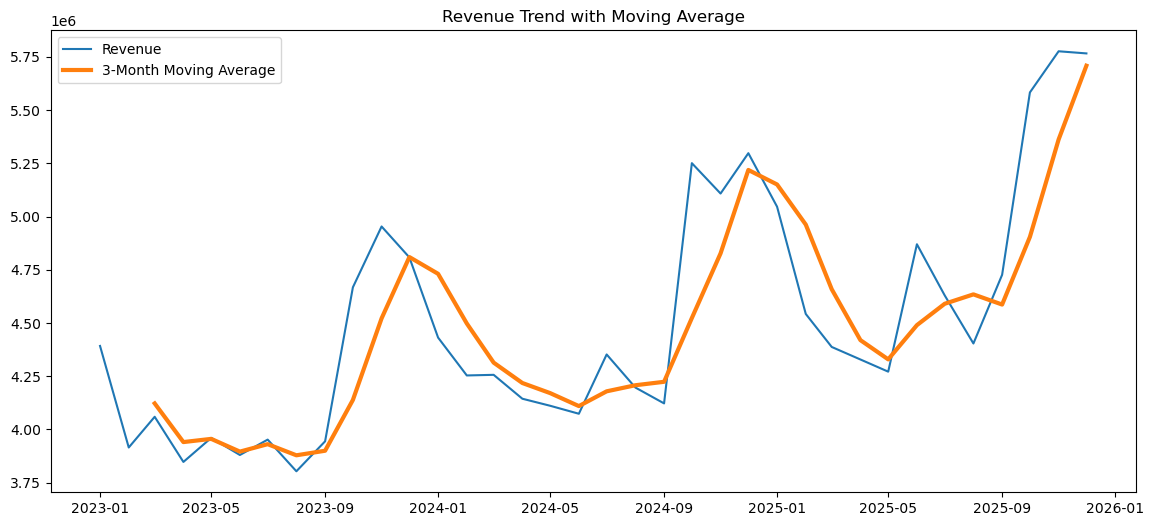

In [17]:
monthly_sales = monthly_sales.to_frame()

monthly_sales['Moving_Average'] = \
monthly_sales['Revenue_INR'].rolling(3).mean()

plt.figure(figsize=(14,6))

plt.plot(
    monthly_sales.index,
    monthly_sales['Revenue_INR'],
    label='Revenue'
)

plt.plot(
    monthly_sales.index,
    monthly_sales['Moving_Average'],
    linewidth=3,
    label='3-Month Moving Average'
)

plt.legend()

plt.title("Revenue Trend with Moving Average")

plt.show()


Top Performing Category:
Smartphones


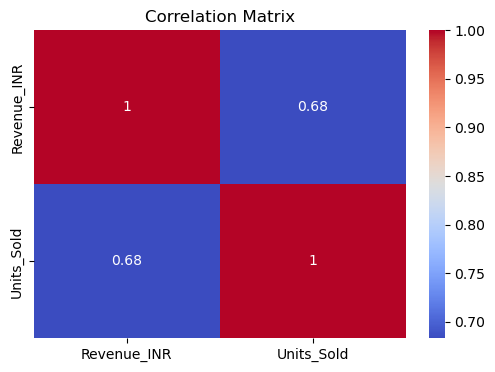


Analysis Completed Successfully!


In [18]:
top_category = category_revenue.idxmax()

print("\nTop Performing Category:")
print(top_category)

# ---------------------------------------
# Correlation Analysis
# ---------------------------------------

corr = df[['Revenue_INR','Units_Sold']].corr()

plt.figure(figsize=(6,4))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.show()

print("\nAnalysis Completed Successfully!")